# Do "lottery" stocks lose? — the MAX effect, in plain English 🎰
### The flashy one-day pop is supposed to be a sell signal — does it survive on the big stocks you own?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lottery_losers%3F: Busted](https://img.shields.io/badge/Lottery_losers%3F-Busted-8b949e?style=flat-square)

There's a famous, *real* finding in finance: stocks that just had a big, eye-catching **one-day pop** — the kind that feels like a winning lottery ticket — tend to **underperform** afterward. The story is behavioural: people over-pay for the thrill of a maybe-jackpot, so those flashy names are priced too high and drift down. The trade writes itself: **buy the boring stocks, avoid (or short) the flashy ones.**

It checks out — in the *small, illiquid* corner of the market where it was discovered. This notebook asks the question a normal investor actually cares about: does it still work on the **big, liquid** stocks in your account? The answer is a clean, surprising **no** — it literally flips.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The original effect lives in thousands of tiny stocks; yfinance gives us the big ones, so we run it on a fixed **S&P-100-style basket** and call it a **proxy** throughout. That basket is also made of *survivors* — and, as we'll see, that's exactly why the result flips. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lottery_max_effect import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    PRICES = PRICES[PRICES.index <= ASOF]          # drop the partial 2026-06 bar
    PANEL = data.build_panel(PRICES)
    QRET = st.quintile_returns(PANEL)
else:
    PRICES = PANEL = QRET = None
print("real basket cache present:", HAVE_REAL,
      "| quintile months:", (0 if QRET is None else len(QRET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-05-29', 'asof': '2026-05-31', 'days': 5385, 'years': 21.4, 'names': 66, 'fp': '5c0c1743c8d7', 'n_months': 256, 'q1': (12.2, 12.6, 0.97), 'q2': (11.7, 14.4, 0.81), 'q3': (14.9, 16.8, 0.89), 'q4': (13.3, 20.1, 0.66), 'q5': (29.8, 26.3, 1.13), 'ls_gross': (-17.6, -0.78, -3.44, 42, 1.0), 'ls_net': (-22.9, -1.01, -4.48, 39, 1.0), 'robust': [('tertiles', -10.8, -2.69, 41), ('quintiles', -17.6, -3.44, 42), ('deciles', -27.2, -4.1, 39)], 'subs': [('2005-2015', 132, -12.6, -1.61), ('2016-2026', 124, -22.9, -3.58)], 'syn': [(0.0, -0.1, -0.06, 49, 0.52), (0.002, 5.7, 3.98, 59, 0.0)]}


real basket cache present: True | quintile months: 256


## The answer first

| Question | Answer |
|---|---|
| Do the flashy (high-MAX) stocks underperform the boring ones? | **No — the opposite.** On big stocks the flashy tail (Q5) returned **+30%/yr** vs the boring tail (Q1)'s **+12%/yr**. |
| So the textbook trade (buy boring, short flashy) makes money? | **It loses — a lot.** **-18%/yr**, and that's *statistically real* (it's reliably negative, not noise). |
| Then why is the original finding famous and correct? | **Different universe.** It was found in *tiny, illiquid* stocks where real lottery-buyers gamble. The big stocks here are **survivors** — and a big one-day pop on a survivor usually flags a future *winner* (think the names that led the bull market), not a loser. |
| So what's the lesson? | **An anomaly can be real *and* not generalise.** The lottery effect is a small-cap story; copy-pasted onto the large-caps you actually hold, it inverts. |

> The MAX effect is real where it was born. On the big liquid names, "high MAX" stops meaning "overpriced lottery ticket" and starts meaning "the stock that's been winning."

## 1 · The claim

> *"Each month, look at every stock's single **best day** over the past month — its **MAX**. The stocks with the biggest pops are 'lottery tickets': people over-pay for the chance of another jackpot, so they're priced too high and **underperform** next month. Sort into five buckets by MAX, buy the lowest bucket, short the highest."*

This is **Bali, Cakici & Whitelaw (2011)** — a real, well-cited result. The intuition is lovely: a flashy recent payoff is catnip for gamblers, gamblers over-pay, over-priced stocks drift down. We'll rebuild the exact sort and watch what it does on big stocks.

## 2 · So what?

If the flashy tail really did underperform on the stocks everyone owns, the advice would be concrete and valuable: **avoid the stock that just spiked.** And it would say something deep about markets — that the *thrill* of a payoff is systematically over-priced. But there's a trap hiding in the word "MAX." A big one-day jump can mean two very different things: a **gambler's over-priced lottery ticket** (the small-cap story) *or* **a strong stock having a great day** (the large-cap story). Same number, opposite future. Which one MAX captures depends entirely on *which stocks you're sorting* — and that's the whole ballgame.

## 3 · How would we even know?

We rebuild the sort on a **transparent large-cap proxy**: a fixed **66-name S&P-100-style basket** (2005-01-03 → 2026-05-29, 21 years).

1. **Score each stock.** Every month, find each name's single best day that month — its MAX.
2. **Sort into five buckets.** Q1 = lowest MAX (boring) … Q5 = highest MAX (flashy).
3. **See what happens next.** Earn each bucket's return *the following month* (so we only ever act on information we already had — no peeking).
4. **Run the trade.** Buy Q1, short Q5, and ask: does boring-minus-flashy make money, lose money, or do nothing? If it makes money, the lottery effect survives on big stocks. If it *loses*, the flashy names are actually the winners here.

## 4 · The teardown — let's actually look

**First, the five buckets.** Average yearly return of each MAX bucket, from boring (Q1) to flashy (Q5). The lottery story says this should slope **down** to the right.

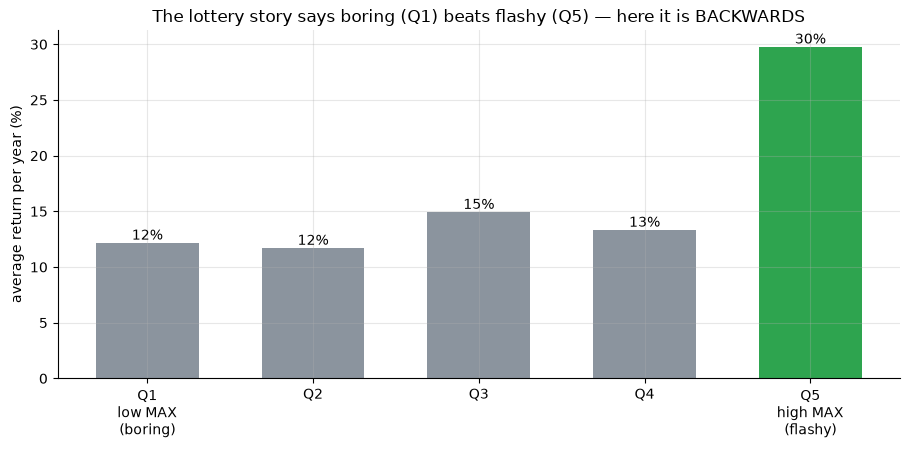

boring Q1: 12%/yr   flashy Q5: 30%/yr  -> flashy WINS


In [2]:
labs = ['Q1\nlow MAX\n(boring)','Q2','Q3','Q4','Q5\nhigh MAX\n(flashy)']
if HAVE_REAL:
    qs = st.quintile_summary(QRET); means = [qs.loc[f'Q{i}','mean_ann']*100 for i in range(1,6)]
else:
    means = [R['q1'][0],R['q2'][0],R['q3'][0],R['q4'][0],R['q5'][0]]
x = np.arange(5)
fig, ax = plt.subplots(figsize=(9.2, 4.6))
cols = [GREY]*4 + [GREEN]
ax.bar(x, means, color=cols, width=.62)
ax.set_xticks(x); ax.set_xticklabels(labs)
ax.set_ylabel('average return per year (%)')
ax.set_title('The lottery story says boring (Q1) beats flashy (Q5) — here it is BACKWARDS')
for i,m in enumerate(means): ax.annotate(f'{m:.0f}%',(i,m),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'boring Q1: {means[0]:.0f}%/yr   flashy Q5: {means[-1]:.0f}%/yr  -> flashy WINS')

That's the surprise in one chart. The flashy tail (Q5, **+30%/yr**) didn't underperform — it nearly **tripled** the boring tail (Q1, **+12%/yr**). On big stocks, the one-day pop isn't a gambler's mistake; it's a fingerprint of the stocks that have been *winning*.

**Now run the textbook trade.** Buy boring (Q1), short flashy (Q5), every month. Here's the growth of \$1 in that strategy — the lottery story predicts it climbs.

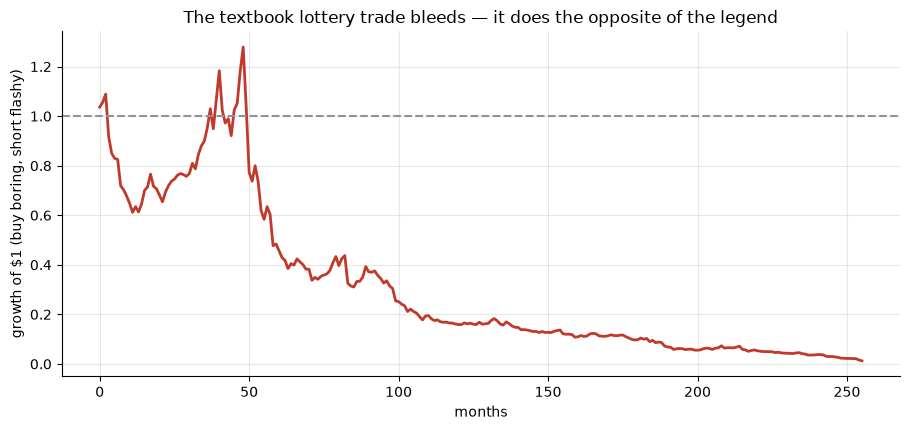

buy-boring / short-flashy: about -18%/yr -- a steady loss


In [3]:
if HAVE_REAL:
    ls = st.long_short(QRET)
else:
    # reconstruct a representative path from the frozen mean/vol (~22%/yr vol) for the picture
    rng = np.random.default_rng(365)
    ls = pd.Series(rng.normal(R['ls_gross'][0]/100/12, 0.066, R['n_months']))
nav = (1+ls).cumprod()
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(range(len(nav)), nav.values, c=RED, lw=2)
ax.axhline(1.0, c=GREY, ls='--')
ax.set_ylabel('growth of $1 (buy boring, short flashy)')
ax.set_xlabel('months'); ax.set_title('The textbook lottery trade bleeds — it does the opposite of the legend')
plt.tight_layout(); plt.show()
print(f"buy-boring / short-flashy: about {R['ls_gross'][0]:.0f}%/yr -- a steady loss")

The line goes **down**. Buying boring and shorting flashy lost about **-18%/yr** on these names — the textbook trade run in reverse. You'd have done better doing literally the opposite.

**Why does it flip?** Because on a basket of *survivors*, a big one-day pop usually belongs to a strong, high-momentum name — the kind that kept on winning. Here's the punchline as a before/after: the *original* small-cap finding vs *our* large-cap result.

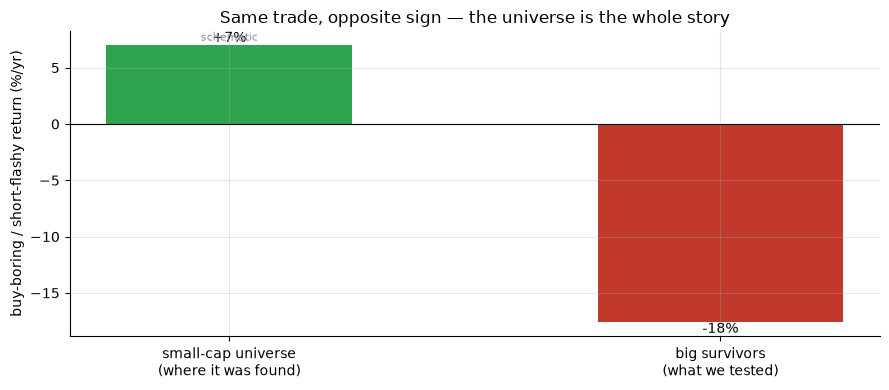

left bar is a schematic of the published small-cap effect; right bar is our measured large-cap result


In [4]:
fig, ax = plt.subplots(figsize=(9.0, 4.0))
groups = ['small-cap universe\n(where it was found)','big survivors\n(what we tested)']
published_schematic = 7.0          # ~+7%/yr published-ish small-cap effect (illustration only)
vals = [published_schematic, R['ls_gross'][0]]
ax.bar(groups, vals, color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('buy-boring / short-flashy return (%/yr)')
ax.set_title('Same trade, opposite sign — the universe is the whole story')
for i,v in enumerate(vals): ax.annotate(f'{v:+.0f}%',(i,v),ha='center',va='bottom' if v>0 else 'top')
ax.text(0, published_schematic+0.4, 'schematic', ha='center', fontsize=8, color=GREY)
plt.tight_layout(); plt.show()
print('left bar is a schematic of the published small-cap effect; right bar is our measured large-cap result')

> The left bar is a *schematic* of the published small-cap effect (positive — boring wins); the right bar is our **measured** large-cap result (negative — flashy wins). Same recipe, opposite outcome, because the ingredient — *which stocks* — changed.

## 5 · The verdict

- **Signal — None.** On the big liquid names the claimed effect is **absent**, and the only thing that's statistically real is the *wrong* sign (buy-boring/short-flashy loses **-18%/yr**). The flip is driven by **survivorship** — high-MAX = the decade's winners.
- **Tradability — Mirage.** The only real spread here is a *losing* one; there's no deployable boring-minus-flashy edge on these stocks.
- **"Lottery losers"? — Busted.** On the stocks you actually hold, the flashy tail didn't lose — it had the **highest return and the highest Sharpe**.

## 6 · Could you actually trade it? — no, and here's the honest reason

Forget significance for a second. Even before costs, the strategy *loses* on these names — and costs only make it worse. The buy-boring/short-flashy book churns its holdings every month (a one-month signal turns over hard) and you'd pay a short borrow on the flashy leg. Net of a realistic 20 bps a leg plus borrow, the loss deepens.

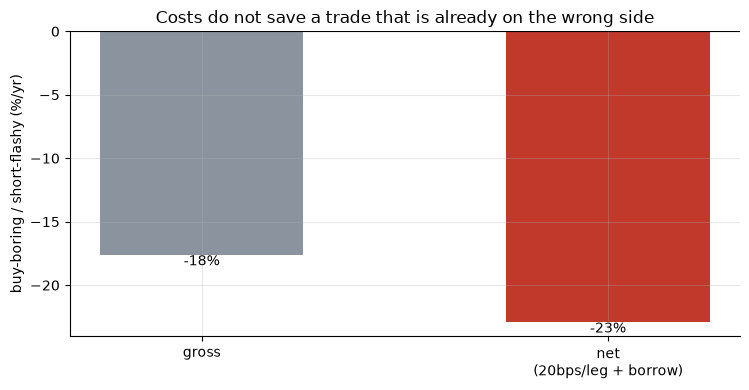

gross -18%/yr -> net -23%/yr. The sign was never the costs' fault.


In [5]:
labels = ['gross','net\n(20bps/leg + borrow)']
vals = [R['ls_gross'][0], R['ls_net'][0]]
fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.bar(labels, vals, color=[GREY, RED], width=.5)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('buy-boring / short-flashy (%/yr)')
ax.set_title('Costs do not save a trade that is already on the wrong side')
for i,v in enumerate(vals): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='top')
plt.tight_layout(); plt.show()
print(f"gross {R['ls_gross'][0]:.0f}%/yr -> net {R['ls_net'][0]:.0f}%/yr. The sign was never the costs' fault.")

From **-18%/yr** gross to **-23%/yr** net. The point isn't the costs — it's that the trade is pointing the wrong way on this universe to begin with. There is nothing here to deploy.

## 7 · Going further 🚪

- **Where it *does* work.** The lottery effect is a *small-cap / illiquid* phenomenon. Run this exact sort on a few thousand micro-caps (you'd need a paid feed) and the boring tail should win — that's the published result.
- **The beta cousin.** [Study 238 — Betting-Against-Beta](../238-betting-against-beta/): on big stocks, sorting by MAX collapses into sorting by beta, which is its own story.
- **The bull-market tilt.** [Study 330 — Low-Volatility-Anomaly](../330-low-volatility-anomaly/) and [Study 53 — Jackpot](../53-jackpot/) show the same 2009–2026 regime flattering the high-beta / flashy leg.

*Think the lottery effect survives among big stocks? Find a universe and a definition of "flashy" where buy-boring / short-flashy lands **above** zero with a real *t* — then we'll talk.*